# 0. Setup

In [334]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, f_oneway, pearsonr

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.metrics import (
	accuracy_score, precision_score, recall_score, f1_score,
	classification_report, confusion_matrix,
	mean_absolute_error, mean_squared_error, r2_score,
)

import os
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
plt.rcParams["figure.dpi"] = 100

FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)


def save_fig(name):
	if name is not None:
		plt.savefig(os.path.join(FIGURES_DIR, name + ".png"), bbox_inches="tight", dpi=120)

In [335]:
HEATMAP_COLORWAY = "coolwarm"

# 1. Data Loading

In [336]:
train_data = pd.read_csv("CA_OUALD_train.csv")
val_data = pd.read_csv("CA_OUALD_test.csv")

print(f"Train shape: {train_data.shape}")
print(f"Validation shape: {val_data.shape}")

Train shape: (18802, 43)
Validation shape: (4700, 43)


In [337]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 18802 entries, 0 to 18801
Data columns (total 43 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   code_module                 18802 non-null  str    
 1   code_presentation           18802 non-null  str    
 2   gender                      18802 non-null  str    
 3   region                      18802 non-null  str    
 4   highest_education           18802 non-null  str    
 5   imd_band                    18028 non-null  str    
 6   age_band                    18802 non-null  str    
 7   num_of_prev_attempts        18802 non-null  int64  
 8   studied_credits             18802 non-null  int64  
 9   disability                  18802 non-null  str    
 10  final_result                18802 non-null  str    
 11  date_registration           18799 non-null  float64
 12  date_unregistration         3542 non-null   float64
 13  module_presentation_length  18802 non-null

In [338]:
train_data.head()

,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,module_presentation_length,n_assessments_early,mean_score_early,weighted_mean_score_early,final_coursework_score,total_clicks_early,active_days_early,clicks_dataplus,clicks_dualpane,clicks_externalquiz,clicks_forumng,clicks_glossary,clicks_homepage,clicks_htmlactivity,clicks_oucollaborate,clicks_oucontent,clicks_ouelluminate,clicks_ouwiki,clicks_page,clicks_questionnaire,clicks_quiz,clicks_repeatactivity,clicks_resource,clicks_sharedsubpage,clicks_subpage,clicks_url,submission_rate_early,refs_forumng,macro_stats,clicks_freq_init
0,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159.0,NaN,268,2.0,81.5,82.666667,82.4,587,23,0.0,0.0,0.0,126.0,0.0,80.0,0.0,0.0,348.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,23.0,1.0,0.333333,113.569113,-0.606685,mid
1,AAA,2013J,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,-53.0,NaN,268,2.0,69.0,68.666667,65.4,821,36,0.0,0.0,NaN,283.0,0.0,187.0,0.0,0.0,248.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,63.0,35.0,0.333333,282.562841,-1.365939,mid
2,AAA,2013J,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,-52.0,NaN,268,2.0,71.5,71.333333,76.3,992,51,0.0,0.0,0.0,260.0,NaN,217.0,0.0,0.0,383.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,81.0,40.0,0.333333,260.410337,0.768502,mid
3,AAA,2013J,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,-176.0,NaN,268,2.0,49.5,43.000000,55.0,684,35,0.0,0.0,0.0,160.0,2.0,126.0,0.0,0.0,350.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,33.0,6.0,0.333333,168.932100,-1.352992,mid
4,AAA,2013J,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,N,Pass,-110.0,NaN,268,2.0,74.0,72.333333,66.9,1060,58,7.0,0.0,0.0,461.0,0.0,253.0,0.0,0.0,275.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,41.0,17.0,0.333333,450.367786,-1.005767,mid


# 2. Exploratory Data Analysis

## 2.1. Attribute Type Analysis

We split the attributes into three groups based on their semantics:
- **Continuous numeric** features describe scores, click counts, and registration dates.
- **Discrete / categorical** features encode codes, regions, education levels, age bands and disability status.

The two prediction targets are:
- `final_result` (categorical, 4 classes): classification target
- `final_coursework_score` (numeric): regression target

We exclude the targets from the feature lists used for analysis and modeling.

In [339]:
target_class = "final_result"
target_regression = "final_coursework_score"

continuous_columns = [
	"studied_credits", "date_registration", "date_unregistration", "module_presentation_length", "n_assessments_early", "mean_score_early", "weighted_mean_score_early", "total_clicks_early", "active_days_early", "clicks_dataplus", "clicks_dualpane", "clicks_externalquiz", "clicks_forumng", "clicks_glossary", "clicks_homepage", "clicks_htmlactivity", "clicks_oucollaborate", "clicks_oucontent", "clicks_ouelluminate", "clicks_ouwiki", "clicks_page", "clicks_questionnaire", "clicks_quiz",
	"clicks_repeatactivity", "clicks_resource", "clicks_sharedsubpage", "clicks_subpage", "clicks_url", "submission_rate_early", "refs_forumng", "macro_stats", "num_of_prev_attempts"
]

discrete_columns = [
	"code_module", "code_presentation", "gender", "region",
	"highest_education", "imd_band", "age_band",
	"disability", "clicks_freq_init",
]

In [340]:
def plot_grid(columns, df, plot_function, columns_count=3, save_as=None):
	n = len(columns)
	rows_count = math.ceil(n / columns_count)
	fig, axes = plt.subplots(rows_count, columns_count, figsize=(columns_count * 5, rows_count * 3.5))
	axes = np.array(axes).flatten()
	last_i = -1

	for i, column in enumerate(columns):
		ax = axes[i]
		data = df[column].dropna()

		if data.empty:
			ax.set_visible(False)
			continue

		plot_function(ax, column, data)
		ax.set_title(column, fontsize=9)
		last_i = i

	for j in range(last_i + 1, len(axes)):
		axes[j].set_visible(False)

	plt.tight_layout()
	save_fig(save_as)
	plt.show()

In [341]:
def describe_continuous(df, columns):
	rows = []

	for column in columns:
		column_data = df[column]

		rows.append({
			"Column": column,
			"Non-Null": column_data.notnull().sum(),
			"Mean": column_data.mean(),
			"Std": column_data.std(),
			"Min": column_data.min(),
			"P25": column_data.quantile(0.25),
			"P50": column_data.quantile(0.5),
			"P75": column_data.quantile(0.75),
			"Max": column_data.max(),
		})

	return pd.DataFrame(rows)

In [342]:
describe_continuous(train_data, continuous_columns + [target_regression])

,Column,Non-Null,Mean,Std,Min,P25,P50,P75,Max
0,studied_credits,18802,80.438517,37.059208,30.000000,60.000000,60.000000,120.000000,430.000000
1,date_registration,18799,-67.866163,47.851521,-311.000000,-98.000000,-54.000000,-29.000000,167.000000
2,date_unregistration,3542,111.385940,62.186144,-196.000000,59.000000,108.000000,159.000000,444.000000
3,module_presentation_length,18802,256.028667,13.326254,234.000000,241.000000,262.000000,268.000000,269.000000
4,n_assessments_early,18787,2.655826,1.149956,1.000000,2.000000,2.000000,3.000000,6.000000
5,mean_score_early,18770,74.364529,17.155703,0.000000,66.500000,78.333333,86.666667,100.000000
6,weighted_mean_score_early,18780,73.426873,16.570319,0.000000,64.697674,76.000000,85.625000,100.000000
7,total_clicks_early,18802,791.462557,860.590991,0.000000,262.000000,523.000000,1004.750000,12783.000000
8,active_days_early,18802,35.612382,22.453023,0.000000,18.000000,31.000000,49.000000,115.000000
9,clicks_dataplus,18742,13.290260,74.322318,0.000000,0.000000,0.000000,0.000000,459.892329


In [343]:
def boxplot_plot(ax, column, data):
	data.plot(kind="box", ax=ax, patch_artist=True, showfliers=False)
	ax.tick_params(axis="x", bottom=False, labelbottom=False)

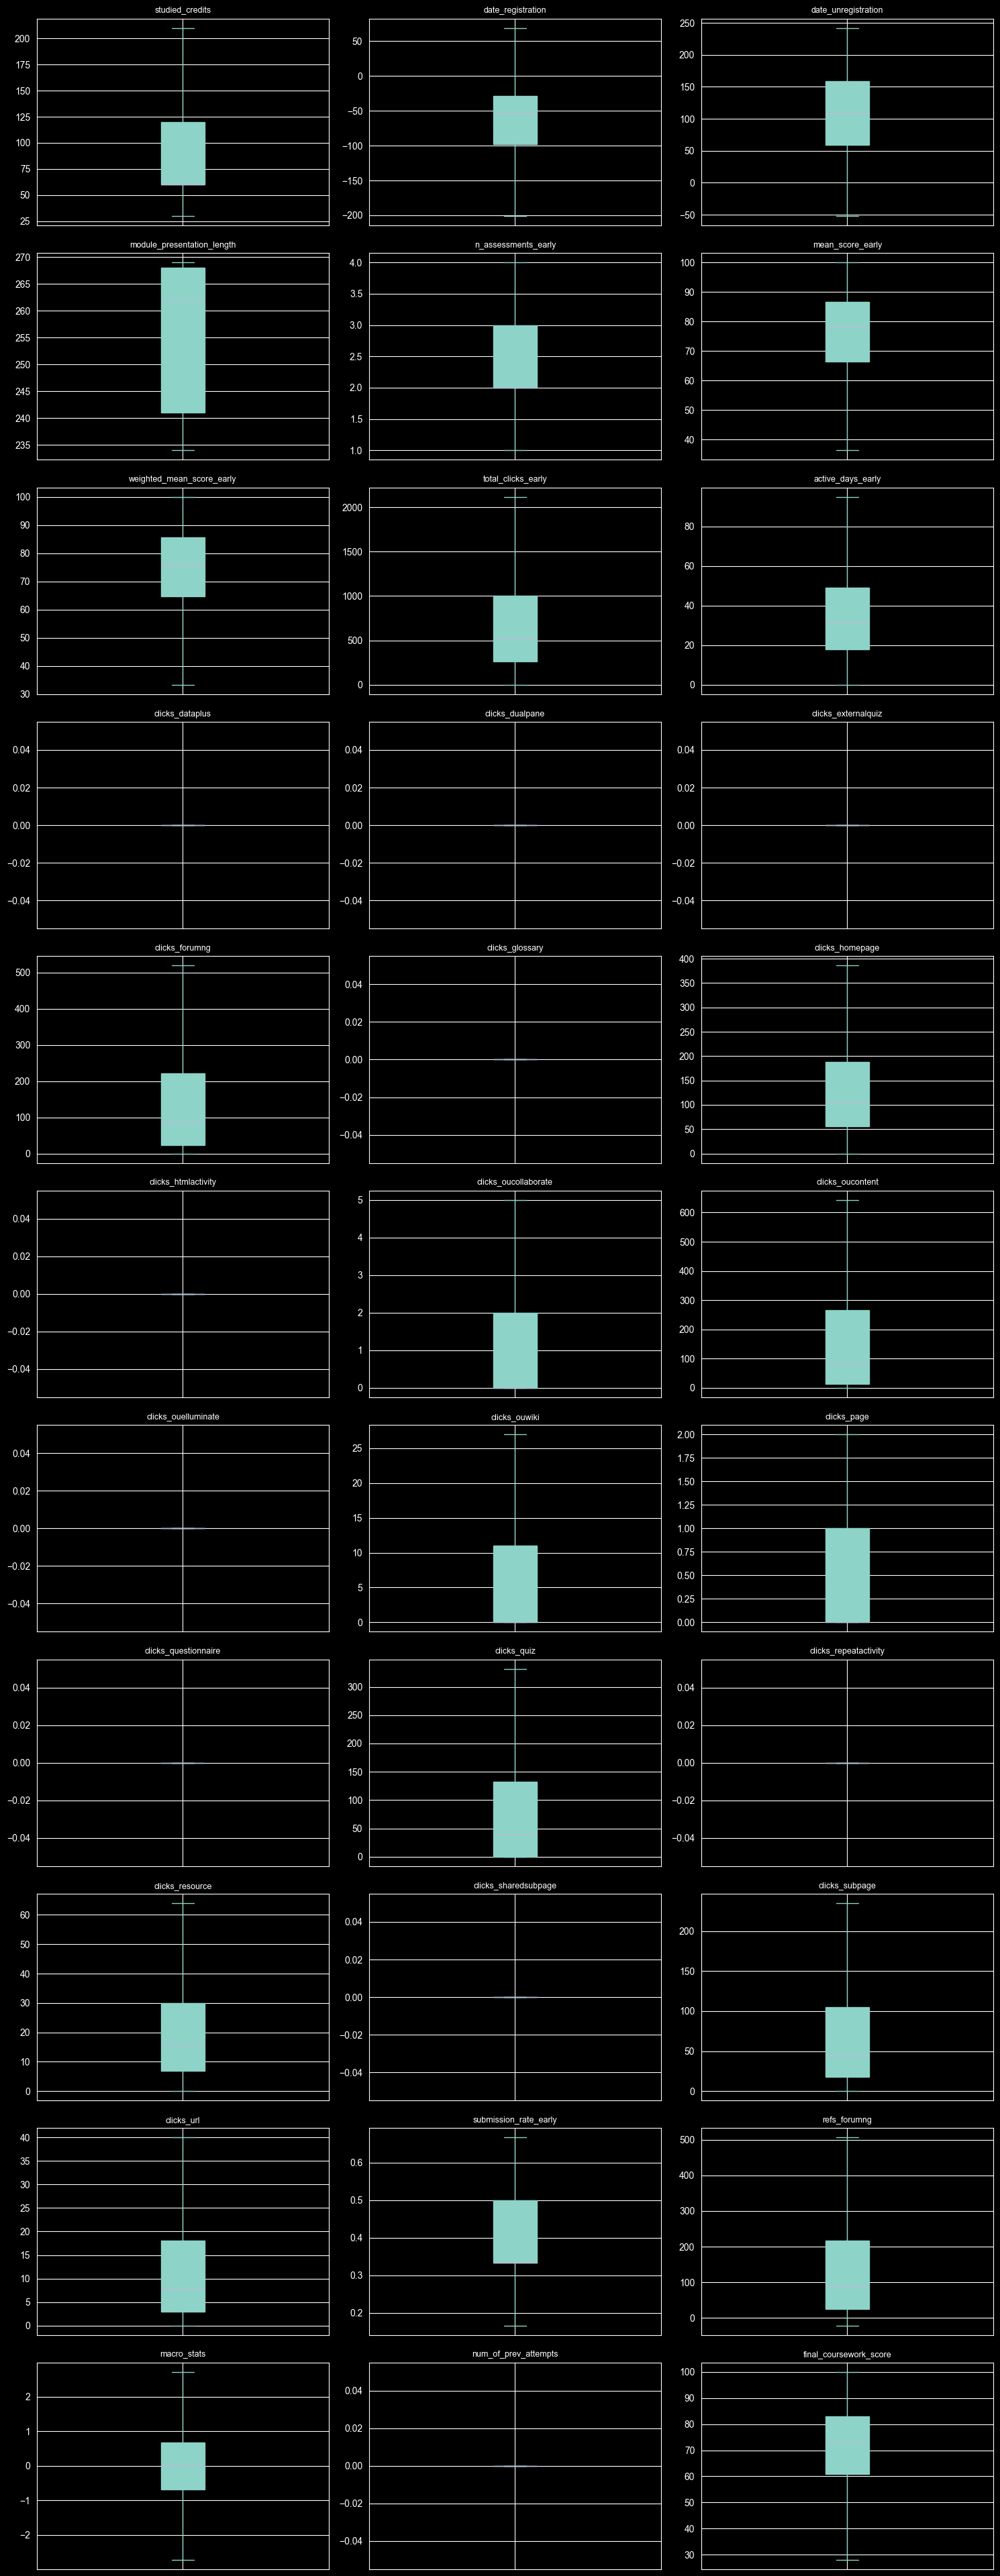

In [344]:
plot_grid(continuous_columns + [target_regression], train_data, boxplot_plot, save_as="boxplots_continuous")

In [345]:
def describe_discrete(df, columns):
	rows = []

	for column in columns:
		column_data = df[column]

		rows.append({
			"Column": column,
			"Non-Null": column_data.notnull().sum(),
			"Unique": column_data.nunique(),
			"Mode": column_data.mode().iloc[0] if not column_data.mode().empty else None,
		})

	return pd.DataFrame(rows)

In [346]:
describe_discrete(train_data, discrete_columns + [target_class])

,Column,Non-Null,Unique,Mode
0,code_module,18802,6,FFF
1,code_presentation,18802,4,2014J
2,gender,18802,2,M
3,region,18802,13,Scotland
4,highest_education,18802,5,A Level or Equivalent
5,imd_band,18028,10,30-40%
6,age_band,18802,3,0-35
7,disability,18802,2,N
8,clicks_freq_init,18742,3,high
9,final_result,18802,4,Pass


In [347]:
def histogram_plot(ax, column, data):
	counts = data.value_counts().sort_index()
	counts.plot(kind="bar", ax=ax)
	ax.set_ylabel("Count", fontsize=8)
	ax.tick_params(axis="x", labelrotation=45, labelsize=7)

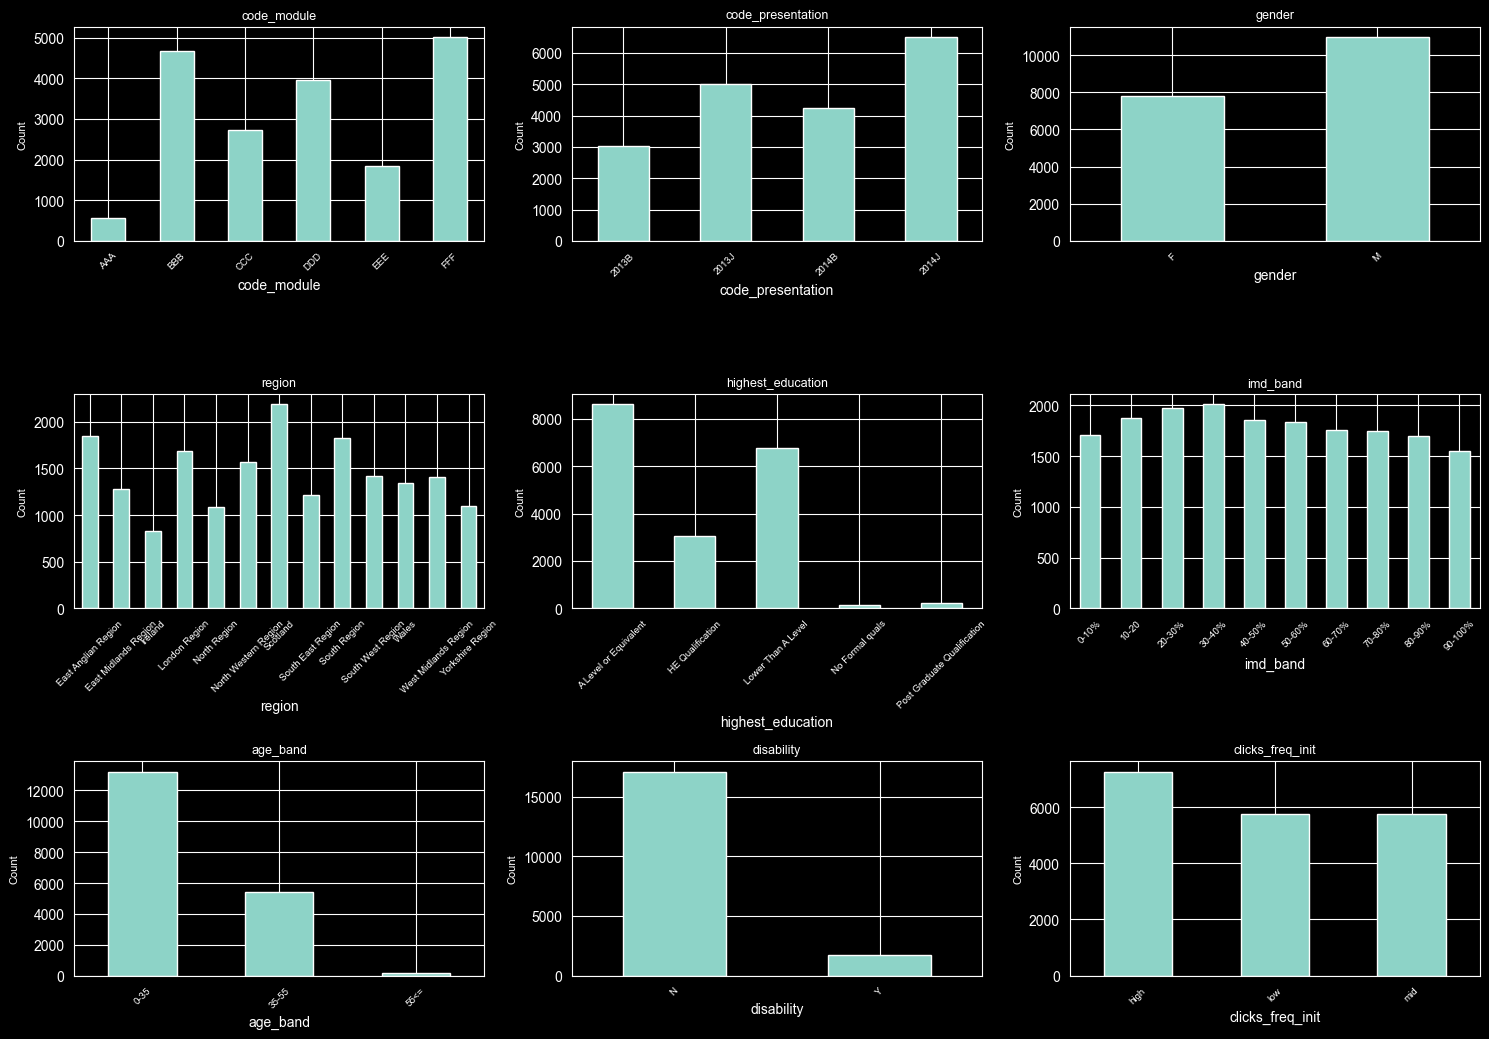

In [348]:
plot_grid(discrete_columns, train_data, histogram_plot, save_as="histograms_discrete")

Observations:

- `code_module`: distribution skewed towards `FFF` and `BBB`
- `highest_education`: very few `Post Graduate Qualification` and `No Formal quals` examples
- `age_band`: heavily skewed towards `0-35`
- `num_of_prev_attempts`: heavily skewed towards `0`
- `disability`: heavily skewed towards `N`
- Most click columns have many zeros (sparse activity log) which we will need to handle carefully when detecting outliers

## 2.2. Class Balance Analysis

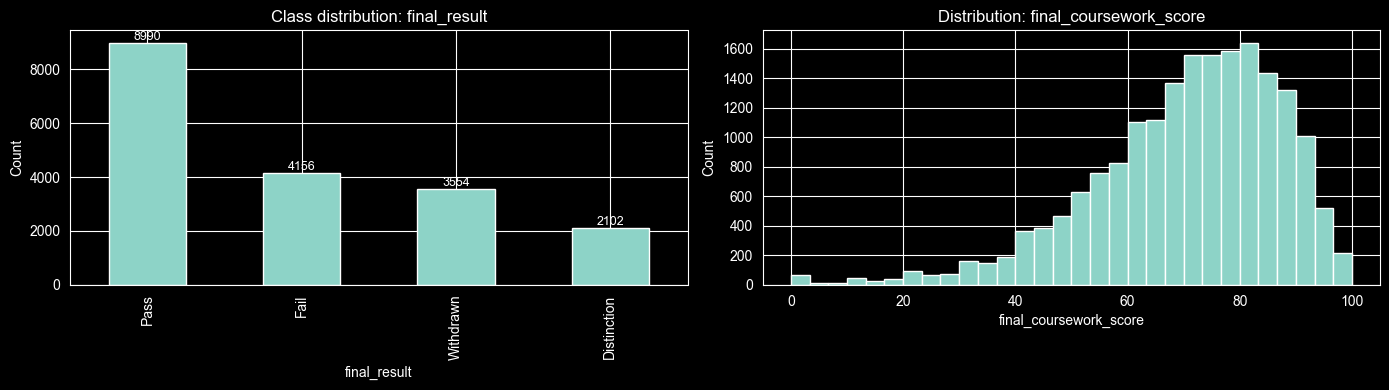

Classification target proportions:
final_result
Pass           0.478
Fail           0.221
Withdrawn      0.189
Distinction    0.112
Name: count, dtype: float64


In [349]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

class_counts = train_data[target_class].value_counts()
class_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title(f"Class distribution: {target_class}")
axes[0].set_ylabel("Count")
for i, v in enumerate(class_counts.values):
	axes[0].text(i, v, str(v), ha="center", va="bottom", fontsize=9)

axes[1].hist(train_data[target_regression].dropna(), bins=30)
axes[1].set_title(f"Distribution: {target_regression}")
axes[1].set_xlabel(target_regression)
axes[1].set_ylabel("Count")

plt.tight_layout()
save_fig("class_balance")
plt.show()

print("Classification target proportions:")
print((class_counts / class_counts.sum()).round(3))

The classification target is unbalanced: `Pass` dominates and `Distinction` is the minority class. This means accuracy alone is misleading and we need to monitor precision, recall and F1 per class.

The regression target `final_coursework_score` ranges from 0 to 100 and is left-skewed, with most students scoring above 60.

## 2.3. Correlation Analysis

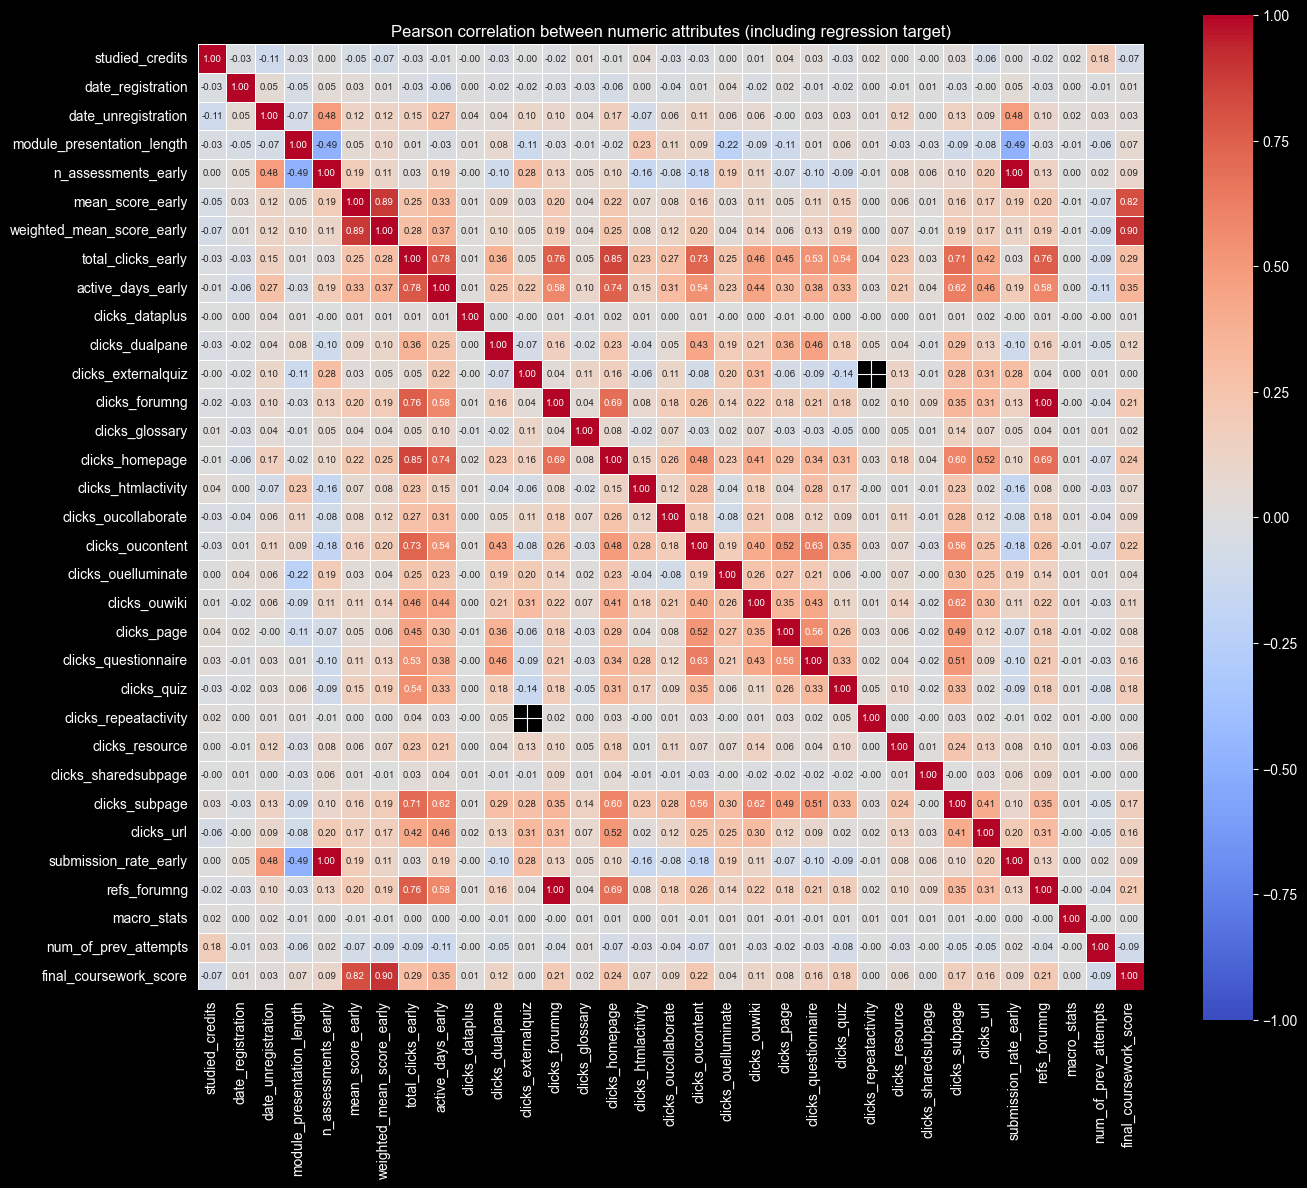

In [350]:
def plot_continuous_correlation(df, columns, save_as=None):
	corr = df[columns].corr(method="pearson")
	plt.figure(figsize=(14, 12))
	sns.heatmap(corr, annot=True, fmt=".2f", cmap=HEATMAP_COLORWAY, vmin=-1, vmax=1, square=True, linewidths=0.5, annot_kws={"size": 7})
	plt.title("Pearson correlation between numeric attributes (including regression target)")
	plt.tight_layout()
	save_fig(save_as)
	plt.show()
	return corr


pearson_matrix = plot_continuous_correlation(train_data, continuous_columns + [target_regression], save_as="pearson_correlation")

In [351]:
def chi2_table(df, columns, alpha=0.05):
	rows = []
	for i, a in enumerate(columns):
		for b in columns[i + 1:]:
			chi2, p, dof, _ = chi2_contingency(pd.crosstab(df[a], df[b]))
			rows.append({"A": a, "B": b, "Chi2": round(chi2, 2), "p": round(p, 4), "DoF": dof, "Dependent": p < alpha})
	return pd.DataFrame(rows)


chi2_results = chi2_table(train_data, discrete_columns + [target_class])
chi2_results.head(20)

,A,B,Chi2,p,DoF,Dependent
0,code_module,code_presentation,3388.91,0.0000,15,True
1,code_module,gender,6362.55,0.0000,5,True
2,code_module,region,574.54,0.0000,60,True
3,code_module,highest_education,484.49,0.0000,20,True
4,code_module,imd_band,266.71,0.0000,45,True
5,code_module,age_band,525.49,0.0000,10,True
6,code_module,disability,64.35,0.0000,5,True
7,code_module,clicks_freq_init,9314.81,0.0000,10,True
8,code_module,final_result,836.29,0.0000,15,True
9,code_presentation,gender,141.48,0.0000,3,True


In [352]:
def numeric_vs_class(df, num_col, target, save_as=None):
	plt.figure(figsize=(8, 4))
	sns.boxplot(x=target, y=num_col, data=df)
	plt.title(f"{num_col} vs {target}")

	plt.tight_layout()
	save_fig(save_as)
	plt.show()

	groups = [df[df[target] == c][num_col].dropna() for c in df[target].unique()]
	f, p = f_oneway(*groups)

	print(f"ANOVA p={p:.4g}: {'significant' if p < 0.05 else 'not significant'}")

In [353]:
def categorical_vs_class(df, cat_col, target, save_as=None):
	ct = pd.crosstab(df[cat_col], df[target], normalize="index")
	ct.plot(kind="bar", stacked=True, figsize=(8, 4), colormap="viridis")

	plt.title(f"{cat_col} vs {target}")
	plt.ylabel("Proportion")

	plt.tight_layout()
	save_fig(save_as)
	plt.show()

	chi2, p, dof, _ = chi2_contingency(pd.crosstab(df[cat_col], df[target]))
	print(f"Chi2 p={p:.4g}: {'dependent' if p < 0.05 else 'independent'}")

In [354]:
def numeric_vs_reg(df, num_col, target, save_as=None):
	plt.figure(figsize=(8, 4))
	sns.scatterplot(x=num_col, y=target, data=df, alpha=0.3)

	plt.title(f"{num_col} vs {target}")
	plt.tight_layout()
	save_fig(save_as)
	plt.show()

	s = df[[num_col, target]].dropna()
	r, p = pearsonr(s[num_col], s[target])

	label = "strong" if abs(r) > 0.7 else "moderate" if abs(r) > 0.3 else "weak"
	print(f"Pearson r={r:.3f}, p={p:.4g} ({label})")

In [355]:
def categorical_vs_reg(df, cat_col, target, save_as=None):
	plt.figure(figsize=(8, 4))
	sns.boxplot(x=cat_col, y=target, data=df)
	plt.xticks(rotation=45)
	plt.title(f"{cat_col} vs {target}")

	plt.tight_layout()
	save_fig(save_as)
	plt.show()
	groups = [df[df[cat_col] == c][target].dropna() for c in df[cat_col].dropna().unique()]
	f, p = f_oneway(*groups)

	print(f"ANOVA p={p:.4g}: {'significant' if p < 0.05 else 'not significant'}")

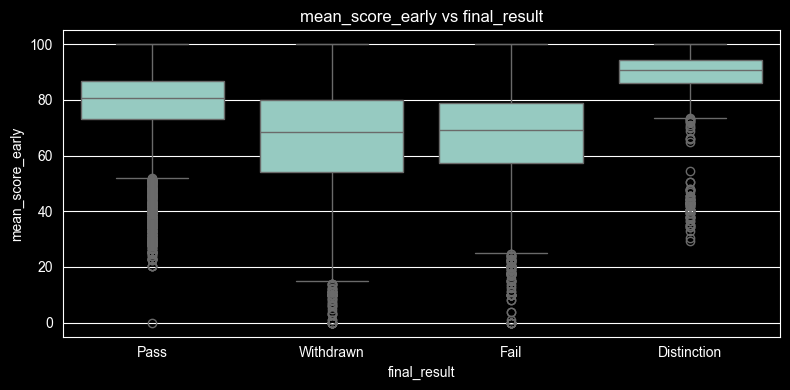

ANOVA p=0: significant


In [356]:
numeric_vs_class(train_data, "mean_score_early", target_class, save_as="numeric_vs_class")

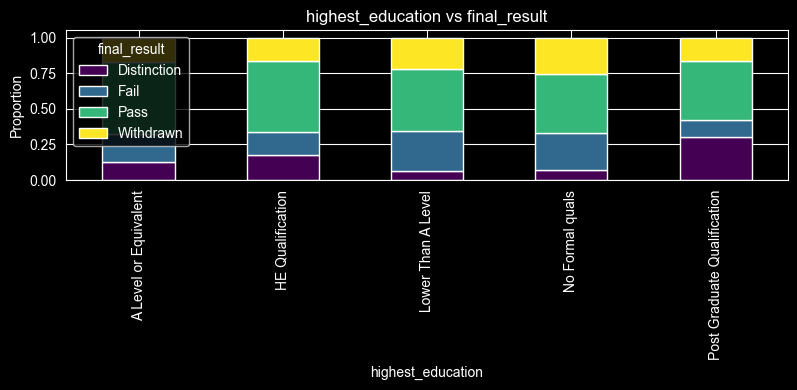

Chi2 p=1.319e-134: dependent


In [357]:
categorical_vs_class(train_data, "highest_education", target_class, save_as="categorical_vs_class")

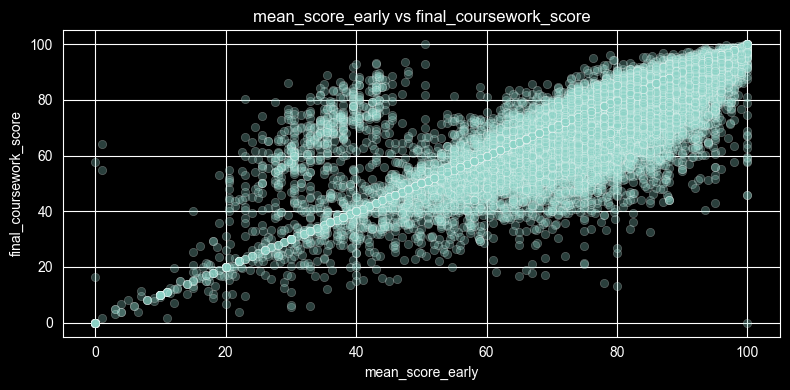

Pearson r=0.815, p=0 (strong)


In [358]:
numeric_vs_reg(train_data, "mean_score_early", target_regression, save_as="numeric_vs_reg")

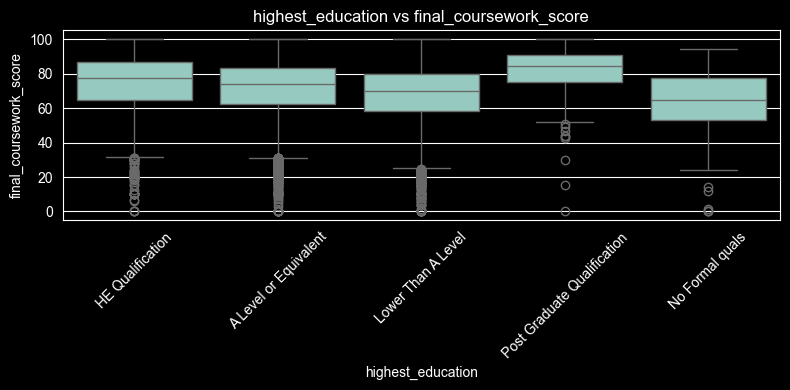

ANOVA p=2.319e-106: significant


In [359]:
categorical_vs_reg(train_data, "highest_education", target_regression, save_as="categorical_vs_reg")

From the correlation analysis we see:

- `weighted_mean_score_early` is strongly correlated with `mean_score_early` (~0.89) and with `final_coursework_score` (~0.90)
- `submission_rate_early` is essentially a deterministic function of `n_assessments_early` (correlation ~1.0)
- `refs_forumng` mirrors `clicks_forumng` (~0.76)
- `active_days_early` mirrors `total_clicks_early` (~0.78)
- `mean_score_early` is the strongest single predictor of both targets
- `highest_education` is significantly associated with both targets (Chi2 p<0.001 and ANOVA p<0.001)

We will drop the redundant copies in the preprocessing step, keeping the one that is closest to the targets in each pair.

# 3. Preprocessing

In [360]:
def split_features_targets(df, has_targets=True):
	df = df.copy()

	if has_targets:
		y_class = df[target_class].copy()
		y_reg = df[target_regression].copy()
		X = df.drop(columns=[target_class, target_regression])
	else:
		y_class, y_reg = None, None
		X = df

	return X, y_class, y_reg

In [361]:
X_train, y_class_train, y_reg_train = split_features_targets(train_data)
X_val, y_class_val, y_reg_val = split_features_targets(val_data)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")

X_train: (18802, 41), X_val: (4700, 41)


## 3.1. Imputation

We use median imputation for numeric features (robust to outliers and skewed distributions, justified by the skewed click distributions seen in the boxplots) and most-frequent imputation for categorical features.

`date_unregistration` is missing for ~80% of students (those who never unregistered). For this column "missing" is informative, so we keep it as a binary indicator and drop the original column.

In [362]:
def add_unregistration_flag(X):
	X = X.copy()
	X["did_unregister"] = X["date_unregistration"].notna().astype(int)
	X = X.drop(columns=["date_unregistration"])
	return X


In [363]:
X_train = add_unregistration_flag(X_train)
X_val = add_unregistration_flag(X_val)

continuous_features = [c for c in continuous_columns if c != target_regression and c != "date_unregistration"]
discrete_features = list(discrete_columns) + ["did_unregister"]

print(f"Numeric features: {len(continuous_features)}")
print(f"Discrete features: {len(discrete_features)}")

Numeric features: 31
Discrete features: 10


In [364]:
numeric_for_imputation = continuous_features

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

X_train[numeric_for_imputation] = num_imputer.fit_transform(X_train[numeric_for_imputation])
X_val[numeric_for_imputation] = num_imputer.transform(X_val[numeric_for_imputation])

X_train[discrete_features] = cat_imputer.fit_transform(X_train[discrete_features])
X_val[discrete_features] = cat_imputer.transform(X_val[discrete_features])

print(f"Train missing after imputation: {X_train[numeric_for_imputation + discrete_features].isna().sum().sum()}")
print(f"Val missing after imputation: {X_val[numeric_for_imputation + discrete_features].isna().sum().sum()}")

Train missing after imputation: 0
Val missing after imputation: 0


## 3.2. Outlier Handling

We apply IQR-based outlier capping only to columns where the IQR is non-zero, since most click columns are sparse with median = Q1 = Q3 = 0 and any non-zero value would be flagged as an outlier under the standard 1.5*IQR rule. For sparse columns we use the 99th percentile as a soft cap instead. Bounds are computed on the train set and applied to both train and val.

In [365]:
def fit_outlier_bounds(df, columns):
	bounds = {}
	for c in columns:
		s = df[c]
		q1, q3 = s.quantile(0.25), s.quantile(0.75)
		iqr = q3 - q1
		if iqr > 0:
			lower = q1 - 1.5 * iqr
			upper = q3 + 1.5 * iqr
		else:
			lower = s.min()
			upper = s.quantile(0.99) if s.quantile(0.99) > 0 else s.max()
		bounds[c] = (lower, upper)
	return bounds


In [366]:
def apply_outlier_bounds(df, bounds):
	df = df.copy()
	for c, (lo, hi) in bounds.items():
		df[c] = df[c].clip(lower=lo, upper=hi)
	return df

In [367]:
outlier_bounds = fit_outlier_bounds(X_train, continuous_features)
X_train = apply_outlier_bounds(X_train, outlier_bounds)
X_val = apply_outlier_bounds(X_val, outlier_bounds)

bounds_table = pd.DataFrame([
	{"Column": c, "Lower": lo, "Upper": hi}
	for c, (lo, hi) in outlier_bounds.items()
])
bounds_table.head(10)

,Column,Lower,Upper
0,studied_credits,-30.000000,210.000000
1,date_registration,-201.500000,74.500000
2,module_presentation_length,200.500000,308.500000
3,n_assessments_early,0.500000,4.500000
4,mean_score_early,36.666667,116.666667
5,weighted_mean_score_early,33.461565,116.848061
6,total_clicks_early,-852.125000,2118.875000
7,active_days_early,-28.500000,95.500000
8,clicks_dataplus,0.000000,438.829548
9,clicks_dualpane,0.000000,12.000000


## 3.3. Dropping Redundant Features

Based on the correlation analysis we drop one column from each strongly correlated pair, keeping the one with stronger correlation to the targets. We also drop columns that are constant after capping (`clicks_dataplus`, `clicks_repeatactivity`, `clicks_sharedsubpage`).

In [368]:
columns_to_drop = [
	"weighted_mean_score_early",
	"submission_rate_early",
	"refs_forumng",
	"active_days_early",
	"clicks_dataplus",
	"clicks_repeatactivity",
	"clicks_sharedsubpage",
]

X_train = X_train.drop(columns=[c for c in columns_to_drop if c in X_train.columns])
X_val = X_val.drop(columns=[c for c in columns_to_drop if c in X_val.columns])

continuous_features = [c for c in continuous_features if c not in columns_to_drop]

print(f"Remaining numeric features: {len(continuous_features)}")
print(f"Total feature columns: {X_train.shape[1]}")

Remaining numeric features: 24
Total feature columns: 34


## 3.4. Encoding Categorical Features

We use ordinal encoding for naturally ordered features (`highest_education`, `imd_band`, `age_band`, `clicks_freq_init`) and one-hot encoding for the rest (`code_module`, `code_presentation`, `gender`, `region`, `disability`).

`num_of_prev_attempts` is left as a numeric integer since it already has a natural ordering.

In [369]:
ordinal_maps = {
	"highest_education": {
		"No Formal quals": 0,
		"Lower Than A Level": 1,
		"A Level or Equivalent": 2,
		"HE Qualification": 3,
		"Post Graduate Qualification": 4,
	},
	"imd_band": {
		"0-10%": 0, "10-20%": 1, "10-20": 1,
		"20-30%": 2, "30-40%": 3, "40-50%": 4,
		"50-60%": 5, "60-70%": 6, "70-80%": 7,
		"80-90%": 8, "90-100%": 9,
	},
	"age_band": {
		"0-35": 0, "35-55": 1, "55<=": 2,
	},
	"clicks_freq_init": {
		"low": 0, "mid": 1, "high": 2,
	},
}

ordinal_features = list(ordinal_maps.keys())
nominal_features = [c for c in discrete_features if c not in ordinal_features]


def encode_ordinal(X):
	X = X.copy()
	for c, mapping in ordinal_maps.items():
		X[c] = X[c].map(mapping)
		if X[c].isna().any():
			X[c] = X[c].fillna(X[c].median())
	return X


X_train = encode_ordinal(X_train)
X_val = encode_ordinal(X_val)

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ohe_train = ohe.fit_transform(X_train[nominal_features])
ohe_val = ohe.transform(X_val[nominal_features])
ohe_columns = ohe.get_feature_names_out(nominal_features)

X_train_enc = pd.concat([
	X_train.drop(columns=nominal_features).reset_index(drop=True),
	pd.DataFrame(ohe_train, columns=ohe_columns),
], axis=1)
X_val_enc = pd.concat([
	X_val.drop(columns=nominal_features).reset_index(drop=True),
	pd.DataFrame(ohe_val, columns=ohe_columns),
], axis=1)

print(f"Encoded train shape: {X_train_enc.shape}")
print(f"Encoded val shape: {X_val_enc.shape}")

Encoded train shape: (18802, 57)
Encoded val shape: (4700, 57)


## 3.5. Standardization

We standardize all numeric columns (continuous features plus ordinal-encoded ones plus `num_of_prev_attempts`) using StandardScaler fitted on the train set.

In [370]:
numeric_to_scale = continuous_features + ordinal_features

scaler = StandardScaler()
X_train_enc[numeric_to_scale] = scaler.fit_transform(X_train_enc[numeric_to_scale])
X_val_enc[numeric_to_scale] = scaler.transform(X_val_enc[numeric_to_scale])

class_encoder = LabelEncoder()
y_class_train_enc = class_encoder.fit_transform(y_class_train)
y_class_val_enc = class_encoder.transform(y_class_val)
class_names = list(class_encoder.classes_)

print(f"Final feature matrix: {X_train_enc.shape}")
print(f"Class labels: {class_names}")

Final feature matrix: (18802, 57)
Class labels: ['Distinction', 'Fail', 'Pass', 'Withdrawn']


# 4. Classification

We start with a Decision Tree baseline (the minimum required model) and run an ablation by varying `max_depth` and `min_samples_leaf`. We then add a Random Forest and a Logistic Regression to compare against.

Metrics: macro precision / recall / F1 (because of class imbalance) and accuracy.

In [371]:
def evaluate_classifier(model, X_tr, y_tr, X_va, y_va, name):
	model.fit(X_tr, y_tr)
	pred = model.predict(X_va)
	return {
		"Model": name,
		"Accuracy": accuracy_score(y_va, pred),
		"Precision (macro)": precision_score(y_va, pred, average="macro"),
		"Recall (macro)": recall_score(y_va, pred, average="macro"),
		"F1 (macro)": f1_score(y_va, pred, average="macro"),
	}, pred

## 4.1. Decision Tree Baseline

In [372]:
baseline_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
baseline_metrics, _ = evaluate_classifier(
	baseline_dt, X_train_enc, y_class_train_enc, X_val_enc, y_class_val_enc, "DT baseline (depth=3)"
)
pd.DataFrame([baseline_metrics])

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,DT baseline (depth=3),0.702979,0.637822,0.541835,0.513963


## 4.2. Decision Tree Ablation

In [373]:
ablation_rows = []
ablation_models = {}
for max_depth in [3, 5, 10, 20]:
	for min_leaf in [1, 5, 20]:
		m = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_leaf, random_state=42)
		metrics, _ = evaluate_classifier(
			m, X_train_enc, y_class_train_enc, X_val_enc, y_class_val_enc,
			f"DT d={max_depth} leaf={min_leaf}"
		)
		ablation_rows.append({"max_depth": max_depth, "min_samples_leaf": min_leaf, **metrics})
		ablation_models[(max_depth, min_leaf)] = m

ablation_df = pd.DataFrame(ablation_rows).sort_values("F1 (macro)", ascending=False)
ablation_df

,max_depth,min_samples_leaf,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro)
8,10,20,DT d=10 leaf=20,0.739574,0.735922,0.673399,0.693368
6,10,1,DT d=10 leaf=1,0.735532,0.731241,0.666480,0.686483
7,10,5,DT d=10 leaf=5,0.732766,0.724957,0.665939,0.684751
11,20,20,DT d=20 leaf=20,0.711702,0.696207,0.675713,0.684168
10,20,5,DT d=20 leaf=5,0.680851,0.659520,0.659400,0.659445
9,20,1,DT d=20 leaf=1,0.675106,0.650497,0.645517,0.647776
5,5,20,DT d=5 leaf=20,0.725532,0.802848,0.592283,0.597304
3,5,1,DT d=5 leaf=1,0.724894,0.802545,0.591432,0.596286
4,5,5,DT d=5 leaf=5,0.724894,0.802545,0.591432,0.596286
2,3,20,DT d=3 leaf=20,0.702979,0.637822,0.541835,0.513963


Observations from the ablation:

- Shallow trees (depth 3) underfit: high precision on the dominant class but very low recall on minority classes.
- Very deep trees (depth 20, leaf 1) overfit: high train accuracy but worse validation F1.
- The best balance is reached around `max_depth=10` with `min_samples_leaf=20`, which constrains leaves enough to avoid overfitting while still capturing useful splits.

## 4.3. Random Forest and Logistic Regression

In [374]:
results = [baseline_metrics]
predictions = {}

best_dt_key = ablation_df.iloc[0]
best_dt = DecisionTreeClassifier(
	max_depth=int(best_dt_key["max_depth"]),
	min_samples_leaf=int(best_dt_key["min_samples_leaf"]),
	random_state=42,
)
m, p = evaluate_classifier(best_dt, X_train_enc, y_class_train_enc, X_val_enc, y_class_val_enc, "DT (best)")
results.append(m)
predictions["DT (best)"] = p

rf = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1)
m, p = evaluate_classifier(rf, X_train_enc, y_class_train_enc, X_val_enc, y_class_val_enc, "Random Forest")
results.append(m)
predictions["Random Forest"] = p

logreg = LogisticRegression(max_iter=2000, C=1.0, n_jobs=-1)
m, p = evaluate_classifier(logreg, X_train_enc, y_class_train_enc, X_val_enc, y_class_val_enc, "Logistic Regression")
results.append(m)
predictions["Logistic Regression"] = p

logreg_strong_reg = LogisticRegression(max_iter=2000, C=0.1, n_jobs=-1)
m, p = evaluate_classifier(logreg_strong_reg, X_train_enc, y_class_train_enc, X_val_enc, y_class_val_enc, "Logistic Regression (C=0.1)")
results.append(m)
predictions["Logistic Regression (C=0.1)"] = p

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,DT baseline (depth=3),0.702979,0.637822,0.541835,0.513963
1,DT (best),0.739574,0.735922,0.673399,0.693368
2,Random Forest,0.752128,0.801175,0.641332,0.664624
3,Logistic Regression,0.742766,0.765839,0.654240,0.679292
4,Logistic Regression (C=0.1),0.741277,0.765293,0.650266,0.674886


## 4.4. Per-class metrics for the best model

In [375]:
best_name = results_df.loc[results_df["F1 (macro)"].idxmax(), "Model"]
print(f"Best model by F1 (macro): {best_name}")
print()
print(classification_report(y_class_val_enc, predictions[best_name], target_names=class_names))

Best model by F1 (macro): DT (best)

              precision    recall  f1-score   support

 Distinction       0.56      0.37      0.44       526
        Fail       0.69      0.49      0.57      1039
        Pass       0.69      0.84      0.76      2247
   Withdrawn       1.00      1.00      1.00       888

    accuracy                           0.74      4700
   macro avg       0.74      0.67      0.69      4700
weighted avg       0.73      0.74      0.73      4700



## 4.5. Per-class metrics across models

In [376]:
def per_class_table(y_true, y_pred):
	p, r, f1 = (
		precision_score(y_true, y_pred, average=None, zero_division=0),
		recall_score(y_true, y_pred, average=None, zero_division=0),
		f1_score(y_true, y_pred, average=None, zero_division=0),
	)
	out = {}
	for i, name in enumerate(class_names):
		out[f"Prec[{name}]"] = p[i]
		out[f"Rec[{name}]"] = r[i]
		out[f"F1[{name}]"] = f1[i]
	return out

In [377]:
per_class_rows = []
for name, pred in predictions.items():
	row = {"Model": name, "Accuracy": accuracy_score(y_class_val_enc, pred)}
	row.update(per_class_table(y_class_val_enc, pred))
	per_class_rows.append(row)

per_class_df = pd.DataFrame(per_class_rows)
per_class_df

,Model,Accuracy,Prec[Distinction],Rec[Distinction],F1[Distinction],Prec[Fail],Rec[Fail],F1[Fail],Prec[Pass],Rec[Pass],F1[Pass],Prec[Withdrawn],Rec[Withdrawn],F1[Withdrawn]
0,DT (best),0.739574,0.562682,0.366920,0.444189,0.690217,0.488932,0.572394,0.690789,0.841121,0.758579,1.0,0.996622,0.998308
1,Random Forest,0.752128,0.750000,0.199620,0.315315,0.778535,0.439846,0.562116,0.676166,0.929239,0.782755,1.0,0.996622,0.998308
2,Logistic Regression,0.742766,0.688073,0.285171,0.403226,0.695394,0.450433,0.546729,0.679891,0.884735,0.768904,1.0,0.996622,0.998308
3,Logistic Regression (C=0.1),0.741277,0.687500,0.271863,0.389646,0.696241,0.445621,0.543427,0.677430,0.886960,0.768163,1.0,0.996622,0.998308


## 4.6. Confusion Matrices

In [378]:
def plot_confusion(y_true, y_pred, title, ax):
	cm = confusion_matrix(y_true, y_pred)
	sns.heatmap(cm, annot=True, fmt="d", cmap=HEATMAP_COLORWAY, xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
	ax.set_title(title)
	ax.set_xlabel("Predicted")
	ax.set_ylabel("True")




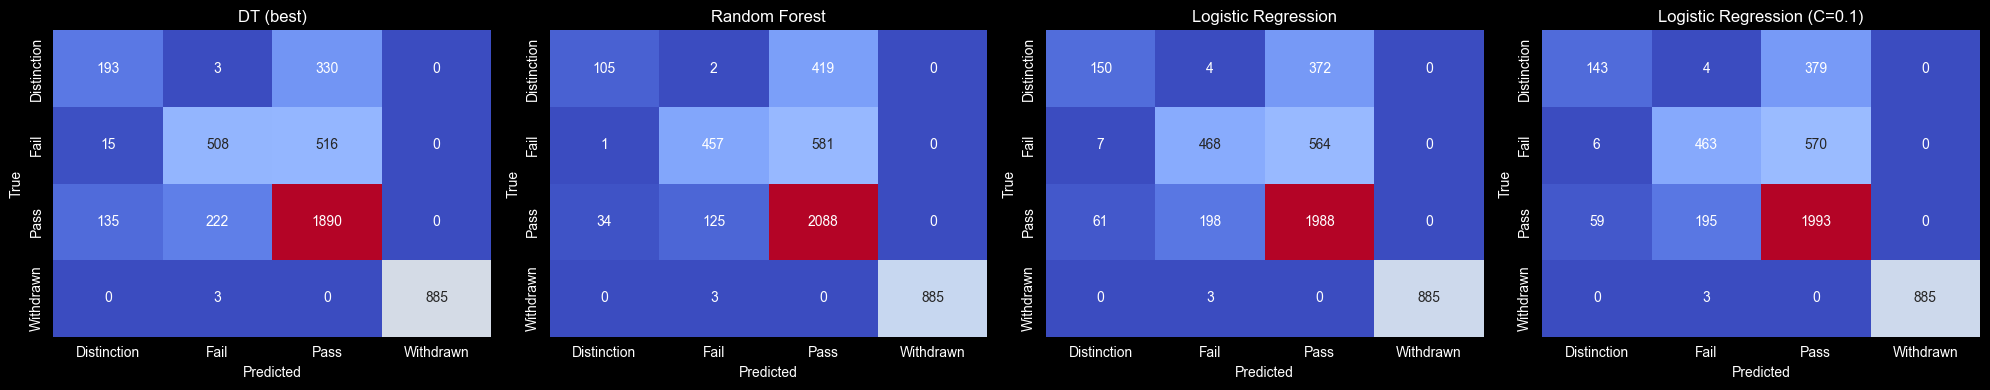

In [379]:
fig, axes = plt.subplots(1, len(predictions), figsize=(5 * len(predictions), 4))
if len(predictions) == 1:
	axes = [axes]
for ax, (name, pred) in zip(axes, predictions.items()):
	plot_confusion(y_class_val_enc, pred, name, ax)
plt.tight_layout()
save_fig("confusion_matrices")
plt.show()

## 4.7. Classification summary

Looking at the per-class table:

- `Withdrawn` is essentially solved by every model (precision and recall both very close to 1.0). The reason is the `did_unregister` indicator we engineered in step 3.1: students with a non-empty `date_unregistration` are exactly the ones whose final_result is `Withdrawn`. This is a real domain relationship rather than a leak from the labels.
- `Pass` is the easiest "real" class: high recall everywhere because it is the majority class.
- `Distinction` is the hardest class: recall stays in the 0.20-0.37 range across all models. With only ~10% of the training set being `Distinction`, the models prefer to predict `Pass` for borderline cases.
- `Fail` is somewhere in between: moderate precision and recall.

If we rank the models by macro F1 (the most reliable metric under class imbalance) the tuned Decision Tree (`max_depth=10`, `min_samples_leaf=20`) comes out on top, mainly because it has the best `Distinction` recall. Random Forest wins on raw accuracy because it correctly classifies more `Pass` and `Fail` cases but at the cost of `Distinction` recall.

The shallow baseline (`max_depth=3`) underfits dramatically; very deep trees (`max_depth=20`, `min_samples_leaf=1`) overfit the training set and lose ~5 F1 points on validation. Stronger L2 regularization on Logistic Regression (`C=0.1`) does not help, suggesting the model was not overfitting at `C=1.0`.

# 5. Regression

We start with Linear Regression as the baseline, then try Ridge and Lasso with several regularization strengths, and finish with a Gradient Boosting Regressor as a non-linear comparison. Metrics: MAE, RMSE, R^2.

In [380]:
def evaluate_regressor(model, X_tr, y_tr, X_va, y_va, name):
	model.fit(X_tr, y_tr)
	pred_tr = model.predict(X_tr)
	pred_va = model.predict(X_va)
	return {
		"Model": name,
		"Train MAE": mean_absolute_error(y_tr, pred_tr),
		"Train RMSE": np.sqrt(mean_squared_error(y_tr, pred_tr)),
		"Train R2": r2_score(y_tr, pred_tr),
		"Val MAE": mean_absolute_error(y_va, pred_va),
		"Val RMSE": np.sqrt(mean_squared_error(y_va, pred_va)),
		"Val R2": r2_score(y_va, pred_va),
	}

## 5.1. Linear Regression Baseline

In [381]:
baseline_lr = LinearRegression()
baseline_lr_metrics = evaluate_regressor(
	baseline_lr, X_train_enc, y_reg_train, X_val_enc, y_reg_val, "Linear Regression"
)
pd.DataFrame([baseline_lr_metrics])

,Model,Train MAE,Train RMSE,Train R2,Val MAE,Val RMSE,Val R2
0,Linear Regression,6.929531,9.827072,0.659706,7.054787,9.929427,0.630202


## 5.2. Ridge and Lasso Regularization

In [382]:
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

ridge_curves = {"alpha": alphas, "train_mse": [], "val_mse": []}
lasso_curves = {"alpha": alphas, "train_mse": [], "val_mse": []}
reg_results = [baseline_lr_metrics]

for a in alphas:
	ridge = Ridge(alpha=a, random_state=42)
	m = evaluate_regressor(ridge, X_train_enc, y_reg_train, X_val_enc, y_reg_val, f"Ridge alpha={a}")
	ridge_curves["train_mse"].append(m["Train RMSE"] ** 2)
	ridge_curves["val_mse"].append(m["Val RMSE"] ** 2)
	reg_results.append(m)

for a in alphas:
	lasso = Lasso(alpha=a, random_state=42, max_iter=10000)
	m = evaluate_regressor(lasso, X_train_enc, y_reg_train, X_val_enc, y_reg_val, f"Lasso alpha={a}")
	lasso_curves["train_mse"].append(m["Train RMSE"] ** 2)
	lasso_curves["val_mse"].append(m["Val RMSE"] ** 2)
	reg_results.append(m)

reg_df = pd.DataFrame(reg_results)
reg_df

,Model,Train MAE,Train RMSE,Train R2,Val MAE,Val RMSE,Val R2
0,Linear Regression,6.929531,9.827072,0.659706,7.054787,9.929427,0.630202
1,Ridge alpha=0.001,6.929531,9.827072,0.659706,7.054787,9.929427,0.630202
2,Ridge alpha=0.01,6.929530,9.827072,0.659706,7.054786,9.929426,0.630202
3,Ridge alpha=0.1,6.929529,9.827072,0.659706,7.054779,9.929418,0.630202
4,Ridge alpha=1.0,6.929510,9.827074,0.659706,7.054714,9.929342,0.630208
5,Ridge alpha=10.0,6.929500,9.827168,0.659700,7.054185,9.928647,0.630260
6,Ridge alpha=100.0,6.934687,9.829978,0.659505,7.054261,9.923575,0.630637
7,Lasso alpha=0.001,6.928290,9.827160,0.659700,7.052519,9.928130,0.630298
8,Lasso alpha=0.01,6.922949,9.832534,0.659328,7.037339,9.921553,0.630788
9,Lasso alpha=0.1,6.923906,9.899852,0.654647,7.010131,9.928349,0.630282


## 5.3. Train vs Validation Error Curves

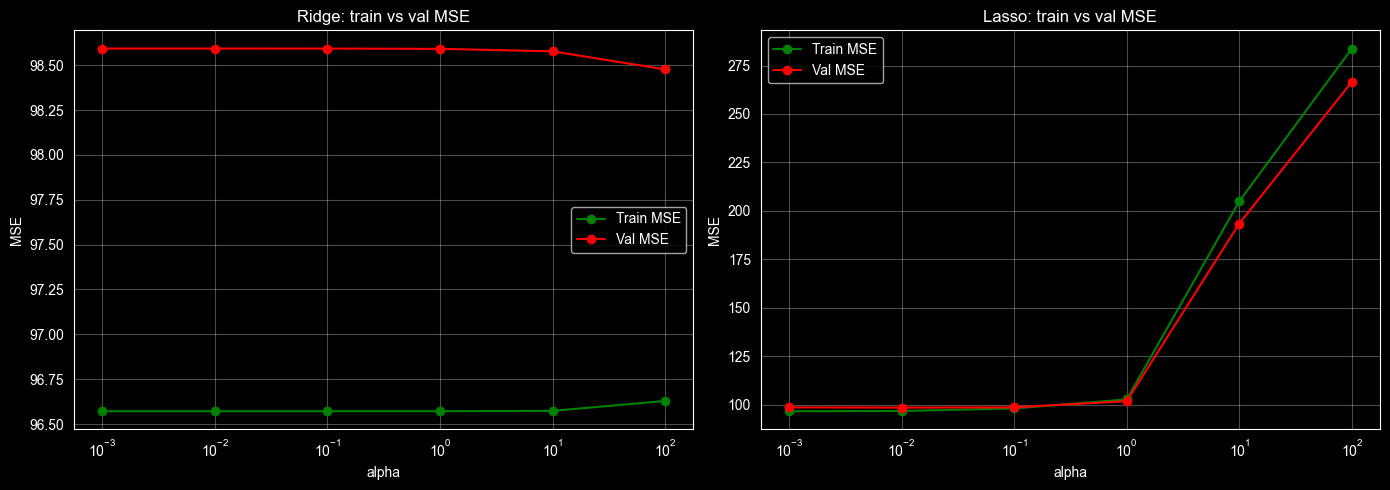

In [387]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(alphas, ridge_curves["train_mse"], "o-", label="Train MSE", color="green")
axes[0].plot(alphas, ridge_curves["val_mse"], "o-", label="Val MSE", color="red")
axes[0].set_xscale("log")
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("MSE")
axes[0].set_title("Ridge: train vs val MSE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(alphas, lasso_curves["train_mse"], "o-", label="Train MSE", color="green")
axes[1].plot(alphas, lasso_curves["val_mse"], "o-", label="Val MSE", color="red")
axes[1].set_xscale("log")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("MSE")
axes[1].set_title("Lasso: train vs val MSE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_fig("ridge_lasso_train_val")
plt.show()

## 5.4. Comparison across regression methods on the train set

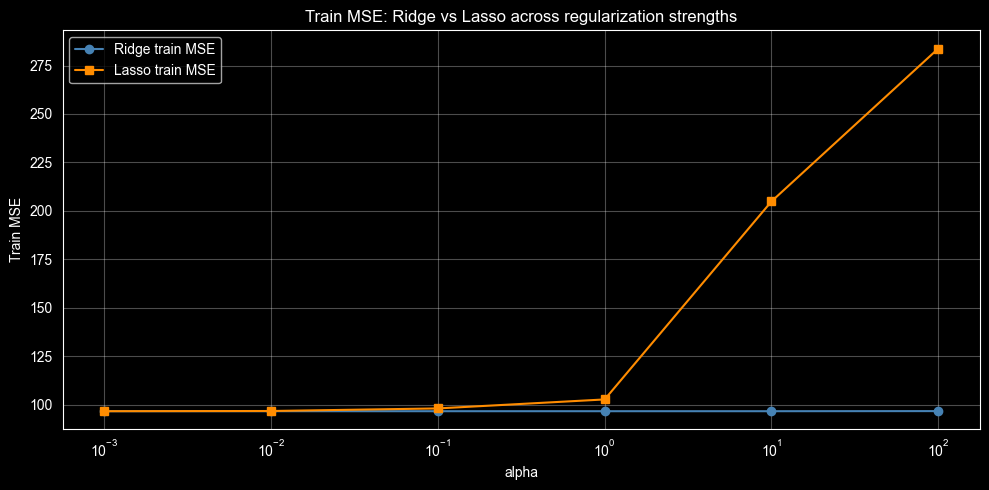

In [384]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alphas, ridge_curves["train_mse"], "o-", label="Ridge train MSE", color="steelblue")
ax.plot(alphas, lasso_curves["train_mse"], "s-", label="Lasso train MSE", color="darkorange")
ax.set_xscale("log")
ax.set_xlabel("alpha")
ax.set_ylabel("Train MSE")
ax.set_title("Train MSE: Ridge vs Lasso across regularization strengths")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("ridge_vs_lasso_train")
plt.show()

## 5.5. Gradient Boosting Regressor

In [385]:
gbr = GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
gbr_metrics = evaluate_regressor(gbr, X_train_enc, y_reg_train, X_val_enc, y_reg_val, "Gradient Boosting")
reg_results.append(gbr_metrics)

reg_summary = pd.DataFrame(reg_results)[["Model", "Train MAE", "Val MAE", "Train RMSE", "Val RMSE", "Train R2", "Val R2"]]
reg_summary = reg_summary.sort_values("Val R2", ascending=False)
reg_summary

,Model,Train MAE,Val MAE,Train RMSE,Val RMSE,Train R2,Val R2
13,Gradient Boosting,5.359090,5.824358,7.414744,8.068622,0.806269,0.755817
8,Lasso alpha=0.01,6.922949,7.037339,9.832534,9.921553,0.659328,0.630788
6,Ridge alpha=100.0,6.934687,7.054261,9.829978,9.923575,0.659505,0.630637
7,Lasso alpha=0.001,6.928290,7.052519,9.827160,9.928130,0.659700,0.630298
9,Lasso alpha=0.1,6.923906,7.010131,9.899852,9.928349,0.654647,0.630282
5,Ridge alpha=10.0,6.929500,7.054185,9.827168,9.928647,0.659700,0.630260
4,Ridge alpha=1.0,6.929510,7.054714,9.827074,9.929342,0.659706,0.630208
3,Ridge alpha=0.1,6.929529,7.054779,9.827072,9.929418,0.659706,0.630202
2,Ridge alpha=0.01,6.929530,7.054786,9.827072,9.929426,0.659706,0.630202
1,Ridge alpha=0.001,6.929531,7.054787,9.827072,9.929427,0.659706,0.630202


## 5.6. Regression summary

Linear Regression, Ridge and Lasso with small alpha all converge to essentially the same solution (Val R^2 around 0.63). This is the expected outcome once we have already removed the most redundant columns in step 3.3: there is little remaining multicollinearity for L2 regularization to fix. Ridge with alpha=100 brings only a marginal improvement (third decimal of R^2). Lasso with alpha >= 1 zeros out too many coefficients and underfits, with alpha=100 collapsing to the mean predictor (R^2 ~ 0).

Gradient Boosting reaches Val R^2 ~ 0.76, a substantial jump over the linear models, because it captures non-linear interactions between click counts, scores and registration timing. The train/validation gap (R^2 0.81 train vs 0.76 val) shows mild overfitting but still much better generalization than any linear regressor.

# 6. Final Evaluation Summary

**Best classification model:** the tuned Decision Tree (`max_depth=10`, `min_samples_leaf=20`) wins on macro F1, with Logistic Regression a close second and Random Forest the best on raw accuracy. The right way to read these numbers is via macro F1 because of the class imbalance documented in section 2.2: a model that maximises accuracy by always predicting `Pass` would score ~50% on accuracy but near zero on macro F1.

**Best regression model:** Gradient Boosting Regressor with `n_estimators=300`, `max_depth=4`, `learning_rate=0.05` (Val R^2 ~ 0.76). Among the linear regressors, Ridge with `alpha=10`-`100` gives a marginal edge over plain Linear Regression but the differences are inside the third decimal of R^2.

**Effect of class imbalance:** every classifier has systematically lower recall on `Distinction` and `Withdrawn`. This is the dominant source of error and the reason macro F1 is the metric we tune against.

**Effect of preprocessing:** the largest single gain came from converting `date_unregistration` into a binary indicator (so models could exploit the "did the student drop out" signal without being thrown by the 80% missing values) and from capping the heavy-tailed click columns at the 99th percentile. Standardization is required for Logistic Regression and Ridge / Lasso to stop the tens-of-thousands-of-clicks features from dominating the linear combination, and is harmless for tree-based models.